##### *Загрузка всех библиотек и датасетов*



In [ ]:
# библиотеки
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn import datasets
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# датасеты
iris = datasets.load_iris()
X = iris.data[:, :2] # Возьмем только два признака для визуализации на плоскости
y = iris.target # 3 класса: 0, 1, 2

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/homeEnergyConsumption.csv', sep=';')

#### 1 Задание

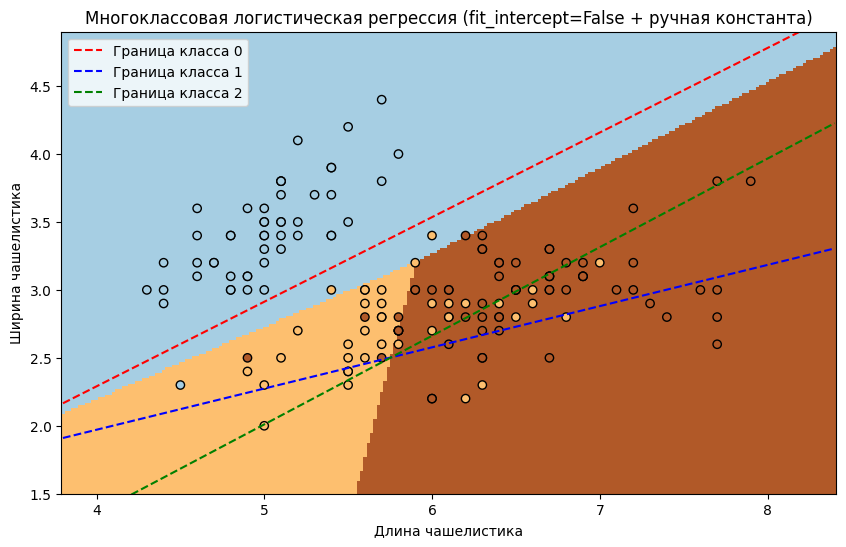

Коэффициенты модели (первый столбец - добавленная константа):
[[ 0.80059233 -2.48966566  3.99890697]
 [ 1.23763338  0.49528644 -1.63324843]
 [-2.21755542  1.15716697 -1.77500049]]


In [ ]:
# Добавление константы (столбец единиц) к признакам
# Это необходимо, так как мы отключим fit_intercept в модели
X_with_const = np.column_stack([np.ones(X.shape[0]), X])

# Обучение модели
# fit_intercept=False — чтобы модель не добавляла свою константу
# multi_class='ovr' (One-vs-Rest) для многоклассовой классификации
model = LogisticRegression(multi_class='ovr', fit_intercept=False, solver='liblinear')
model.fit(X_with_const, y)

# Визуализация результатов
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Для предсказания на сетке также добавляем константу
grid_points = np.c_[np.ones(xx.ravel().shape[0]), xx.ravel(), yy.ravel()]
Z = model.predict(grid_points)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 6))
plt.pcolormesh(xx, yy, Z, cmap=plt.cm.Paired, shading='auto')

# Отрисовка разделяющих гиперплоскостей
# Уравнение: w0*1 + w1*x1 + w2*x2 = 0  =>  x2 = -(w1*x1 + w0) / w2
colors = ['red', 'blue', 'green']
for i, color in enumerate(colors):
    w = model.coef_[i] # Коэффициенты для i-го класса
    # w[0] - константа, w[1] - вес 1-го признака, w[2] - вес 2-го признака
    line_x = np.array([x_min, x_max])
    line_y = -(w[1] * line_x + w[0]) / w[2]
    plt.plot(line_x, line_y, label=f'Граница класса {i}', color=color, linestyle='--')

plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.Paired)
plt.xlabel('Длина чашелистика')
plt.ylabel('Ширина чашелистика')
plt.title('Многоклассовая логистическая регрессия (fit_intercept=False + ручная константа)')
plt.legend()
plt.ylim(y_min, y_max)
plt.show()

# Вывод коэффициентов
print("Коэффициенты модели (первый столбец - добавленная константа):")
print(model.coef_)

#### 2 Задание

*Предварительный анализ набора данных*

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   YearMade                 1001 non-null   int64 
 1   WallType                 1001 non-null   object
 2   RoofType                 834 non-null    object
 3   NumOfBedrooms            1001 non-null   int64 
 4   StovenFuelType           1001 non-null   object
 5   HeatingEquipmentType     962 non-null    object
 6   HeatingEquipmentAge      1001 non-null   object
 7   NumOfRoomsHeated         1001 non-null   int64 
 8   FuelUsedForWaterHeating  1001 non-null   object
 9   WaterHeaterSize          961 non-null    object
 10  AirConditioning          1001 non-null   object
 11  NumOfRoomsCooled         1001 non-null   int64 
 12  NumOfWindows             1001 non-null   int64 
 13  TotalSquareHeated        1001 non-null   int64 
 14  TotalSquareCooled        1001 non-null  

*Получить список категориальных и числовых признаков*

*Вывести количество объектов в наборе для всех категорий*

In [ ]:
from pandas.api.types import is_numeric_dtype

listOfCategoricalFeatures = []
listOfNumericalFeatures = []

for column in df.columns:
    if not (is_numeric_dtype(df[column])):
        print(f'\nПризнак: {column} (категориальный)')
        print('Значения и их количество в наборе:')
        print(df[column].value_counts())
        listOfCategoricalFeatures.append(column)
    else:
        listOfNumericalFeatures.append(column)

# Удаляем целевую переменную из числовых признаков, если нужно
if 'AirConditioning' in listOfNumericalFeatures:
    listOfNumericalFeatures.remove('AirConditioning')

print(f'\nСписок категориальных признаков: {listOfCategoricalFeatures}')
print(f'Список числовых признаков: {listOfNumericalFeatures}')


Признак: WallType (категориальный)
Значения и их количество в наборе:
WallType
Siding         324
Brick          258
Wood           182
Stucco         160
Concrete        46
Composition     15
Stone           12
Other            4
Name: count, dtype: int64

Признак: RoofType (категориальный)
Значения и их количество в наборе:
RoofType
Composition Shingles     491
Asphalt                  172
Wood Shingles             57
Metal                     48
Ceramic or Clay Tiles     36
Concrete Tiles            17
Other                      7
Slate                      6
Name: count, dtype: int64

Признак: StovenFuelType (категориальный)
Значения и их количество в наборе:
StovenFuelType
Electricity    559
Natural Gas    320
-               93
Propane/LPG     25
Other Fuel       4
Name: count, dtype: int64

Признак: HeatingEquipmentType (категориальный)
Значения и их количество в наборе:
HeatingEquipmentType
Central Warm-Air Furnace          630
Steam or Hot Water System         109
Heat Pump  

*Удалить строки из набора, где для каждого числового признака его
значения меньше процентиля 2.5 и больше процентиля 97.5*

In [ ]:
initial_shape = df.shape
print(f"Изначальный размер: {initial_shape}")
print()

for column in listOfNumericalFeatures:
    minLimit = df[column].quantile(0.025)
    maxLimit = df[column].quantile(0.975)
    print(f"{column}: [{minLimit:.2f}, {maxLimit:.2f}]")
    df = df.loc[(df[column] >= minLimit) & (df[column] <= maxLimit)]

print(f"\nРазмер после удаления выбросов: {df.shape}")
print(f"Удалено строк: {initial_shape[0] - df.shape[0]}")

Изначальный размер: (1001, 16)

YearMade: [1920.00, 2006.00]
NumOfBedrooms: [1.00, 5.00]
NumOfRoomsHeated: [-2.00, 10.00]
NumOfRoomsCooled: [-1.00, 9.00]
NumOfWindows: [10.00, 60.00]
TotalSquareHeated: [0.00, 4054.32]
TotalSquareCooled: [0.00, 3261.38]
ElectricityConsumption: [2012.70, 28928.10]

Размер после удаления выбросов: (837, 16)
Удалено строк: 164


*Заменить все отсутствующие значения для признака WaterHeaterSize
(размер водонагревателя) значением моды*

In [ ]:
print("Значения до обработки:")
print(df['WaterHeaterSize'].value_counts(dropna=False))

# Замена пропущенных значений модой
modeWaterHeaterSize = df['WaterHeaterSize'].mode()[0]
print(f"\nМода: {modeWaterHeaterSize}")
df['WaterHeaterSize'] = df['WaterHeaterSize'].replace('None', modeWaterHeaterSize)

# Кодирование порядкового признака
waterHeaterSizeDict = {'Small': 1, 'Medium': 2, 'Large': 3}
df['WaterHeaterSize'] = df['WaterHeaterSize'].map(waterHeaterSizeDict)

print("Значения после кодирования:")
print(df['WaterHeaterSize'].value_counts())

Значения до обработки:
WaterHeaterSize
Medium    437
Large     241
Small     122
NaN        37
Name: count, dtype: int64

Мода: Medium
Значения после кодирования:
WaterHeaterSize
2.0    437
3.0    241
1.0    122
Name: count, dtype: int64


*Устранить отрицательные значения в столбце NumOfRoomsCooled
(количество комнат с кондиционированием)*

In [ ]:
negative_count = (df['NumOfRoomsCooled'] < 0).sum()
print(f"Отрицательных значений до: {negative_count}")

df.loc[df['NumOfRoomsCooled'] < 0, 'NumOfRoomsCooled'] = 0

negative_count_after = (df['NumOfRoomsCooled'] < 0).sum()
print(f"Отрицательных значений после: {negative_count_after}")

Отрицательных значений до: 341
Отрицательных значений после: 0


*Удалить строки, в которых не содержится значения по типу системы
отопления (HeatingEquipmentType)*

In [ ]:
missing_before = df['HeatingEquipmentType'].isnull().sum()
print(f"Пропущенных значений до: {missing_before}")

df = df.dropna(subset=['HeatingEquipmentType'])

missing_after = df['HeatingEquipmentType'].isnull().sum()
print(f"Пропущенных значений после: {missing_after}")
print(f"Размер датасета: {df.shape}")

Пропущенных значений до: 32
Пропущенных значений после: 0
Размер датасета: (805, 16)


*Для атрибутов RoofType (тип крыши), StovenFuelType (тип топлива для печи)
в случае их отсутствия поставить значение Unknown*

In [ ]:
# RoofType
print(f"RoofType - пропусков до: {df['RoofType'].isna().sum()}")
df['RoofType'] = df['RoofType'].replace(np.nan, 'Unknown')
print(f"RoofType - пропусков после: {df['RoofType'].isna().sum()}")

# StovenFuelType
print(f"\nStovenFuelType - пропусков до: {(df['StovenFuelType'] == '-').sum()}")
df['StovenFuelType'] = df['StovenFuelType'].replace('-', 'Unknown')
print(f"StovenFuelType - пропусков после: {(df['StovenFuelType'] == '-').sum()}")

RoofType - пропусков до: 0
RoofType - пропусков после: 0

StovenFuelType - пропусков до: 0
StovenFuelType - пропусков после: 0


*Закодировать значения HeatingEquipmentAge (возраст системы отопления)*

In [ ]:
mainHeatingEquipmentAgeDict = {
    '<2 Years old': 1,
    '2-4 Years old': 2,
    '5-9 Years old': 3,
    '10-14 Years old': 4,
    '15-19 Years old': 5,
    '>20 Years old': 6
}

print("Исходные значения:")
print(df['HeatingEquipmentAge'].value_counts())

df['HeatingEquipmentAge'] = df['HeatingEquipmentAge'].map(mainHeatingEquipmentAgeDict)

print("\nЗакодированные значения:")
print(df['HeatingEquipmentAge'].value_counts().sort_index())

Исходные значения:
HeatingEquipmentAge
>20 Years old      248
5-9 Years old      229
10-14 Years old    182
2-4 Years old      142
15-19 Years old     99
<2 Years old        88
Not Applicable      13
Name: count, dtype: int64

Закодированные значения:
HeatingEquipmentAge
1.0     88
2.0    142
3.0    229
4.0    182
5.0     99
6.0    248
Name: count, dtype: int64


*Удалить из набора объекты с редкими категориями (чей процент
встречаемости для оставшихся строк меньше 3)*

In [ ]:
threshold = df.shape[0] * 0.03
print(f"Пороговое значение: {threshold:.0f} записей (3%)")
print()

for column in listOfCategoricalFeatures:
    if column in df.columns:
        counts = df[column].value_counts()
        rare_categories = counts[counts < threshold].index.tolist()
        if rare_categories:
            print(f"{column}: удалены редкие категории: {rare_categories}")
            df = df[~df[column].isin(rare_categories)]
        else:
            print(f"{column}: редких категорий не найдено")

print(f"\nИтоговый размер датасета: {df.shape}")

Пороговое значение: 24 записей (3%)

WallType: редких категорий не найдено
RoofType: редких категорий не найдено
StovenFuelType: редких категорий не найдено
HeatingEquipmentType: редких категорий не найдено
HeatingEquipmentAge: редких категорий не найдено
FuelUsedForWaterHeating: редких категорий не найдено
WaterHeaterSize: редких категорий не найдено
AirConditioning: редких категорий не найдено

Итоговый размер датасета: (789, 16)


*Сохранить полученный набор в файл*

In [ ]:
output_file = 'homeEnergyConsumption_cleaned.csv'
df.to_csv(output_file, index=False)
print(f"Файл сохранён: {output_file}")

Файл сохранён: homeEnergyConsumption_cleaned.csv


*Финальная проверка*

In [ ]:
print("\nФинальная информация:")
print(f"Размер: {df.shape}")
print(f"\nПропущенные значения:\n{df.isnull().sum()}")
print(f"\nТипы данных:\n{df.dtypes}")


Финальная информация:
Размер: (789, 16)

Пропущенные значения:
YearMade                     0
WallType                     0
RoofType                   141
NumOfBedrooms                0
StovenFuelType               0
HeatingEquipmentType        35
HeatingEquipmentAge         10
NumOfRoomsHeated             0
FuelUsedForWaterHeating      0
WaterHeaterSize             17
AirConditioning              0
NumOfRoomsCooled             0
NumOfWindows                 0
TotalSquareHeated            0
TotalSquareCooled            0
ElectricityConsumption       0
dtype: int64

Типы данных:
YearMade                     int64
WallType                    object
RoofType                    object
NumOfBedrooms                int64
StovenFuelType              object
HeatingEquipmentType        object
HeatingEquipmentAge        float64
NumOfRoomsHeated             int64
FuelUsedForWaterHeating     object
WaterHeaterSize             object
AirConditioning             object
NumOfRoomsCooled            